# Revealing the Domains of Scene Evaluation from Natural Language

This project aims to understand which domains people spontaneously rely on when visually perceiving outdoor scenes, addressing a gap in prior research that has focused mainly on predefined categories in scene perception/categorization.

## Data Analysis Script

The following pipeline aims to analyze the language participants use in written free responses in order to understand the underlying structure of scene perception.

In [16]:
# Magic commands
%reset -f
%matplotlib inline
# %matplotlib widget
# %matplotlib nbagg
# use osx or widget instead of inline on mac — pip install ipympl to allow widget to work
%config InlineBackend.figure_format = "retina" # High-res graphs (rendered irrelevant by svg option below)
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight"} # No extra white space
%config InlineBackend.figure_format = "svg" # png is default

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # a helpful package for making plots
import sys
from pathlib import Path

# Extra imports

# 1. data cleaning
import ast
import string

# 2. word frequency
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
# word co-occurrence
from collections import defaultdict
from itertools import combinations
# topic modeling LDA
from sklearn.decomposition import LatentDirichletAllocation


# import palettable

## 0. Load Data

The following code loads and checks the raw data (.csv). 

The BCOG200 project uses the example dataset "main_data.csv", which is the text response collected from participants who viewed images of cars. Later, the example dataset will be replaced with the actual data collected for the scene evaluation project. 

In [17]:
#load_data function
def load_data(file_name):
    data_path = Path("data") / file_name
    data = pd.read_csv(data_path)
    return data

In [18]:
#load "main_data.csv"
raw_data = load_data("main_data.csv")

#check
raw_data.head()

,rt,url,experiment_phase,refresh_count,trial_type,trial_index,time_elapsed,experiment_name,assignment_id,hit_id,...,window_width,window_height,form_name,form_id,instructions_viewed_count,view_history,responses,stimulus,form_data,is_prolific
0,39511.6,NaN,main,0,face-description-trial,4,84918,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a blue car just sitting in an empty pa...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False
1,27368.1,NaN,main,0,face-description-trial,5,112393,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a white car in a parking lot it might ...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False
2,29392.1,NaN,main,0,face-description-trial,6,141895,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a gray possibly sitting in a driveway ...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False
3,18590.4,NaN,main,0,face-description-trial,7,160595,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a blue sedan in a parking lot with tre...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False
4,24727.6,NaN,main,0,face-description-trial,8,185433,car_description_survey_2023-05-14,3IGI0VL64E0GWXBBNF2YI1R1DLHNO8,372AGES0JALLIKK2RB1ALEREDS7XRN,...,NaN,NaN,NaN,NaN,NaN,NaN,{'Q0': 'a red car that is more of an older mod...,https://tlab-objects.s3.us-east-2.amazonaws.co...,NaN,False


As seen above, the text responses are recorded under a column named "responses." This column will be made into a variable named "response_col."

In [19]:
response_col = raw_data.responses

#check
response_col

0       {'Q0': 'a blue car just sitting in an empty pa...
1       {'Q0': 'a white car in a parking lot it might ...
2       {'Q0': 'a gray possibly sitting in a driveway ...
3       {'Q0': 'a blue sedan in a parking lot with tre...
4       {'Q0': 'a red car that is more of an older mod...
                              ...                        
1095    {'Q0': 'I worry about small cars like this. I ...
1096    {'Q0': 'It seems exciting because of the red c...
1097    {'Q0': "It seems like an older model, somethin...
1098    {'Q0': "I really like this car, and not just b...
1099    {'Q0': 'This car is way too boxy. I feel like ...
Name: responses, Length: 1100, dtype: str

Before moving on to data cleaning, the "response_col" will be checked for any missing values. 

In [20]:
"Missing values:", response_col.isna().any()

('Missing values:', np.False_)

The example dataset returns "False" from the code above, indicating that no NaN value was detected in the response column. If the output were "True," the very line will be checked and treated.

## 1. Preprocess Responses

The preprocessing includes changing the data into an easily manipulable format and cleaning the data.

The "response_col" is in strings, such as "{'Q0': response text}". To make the content easier to manipulate, each string will be converted into a dictionary object.
The try & except below filters out values that cannot be safely parsed into valid Python dictionary objects (e.g., responses not in the expected format).

In [21]:
def string_to_dict(responses):
    try:
        return ast.literal_eval(responses)
    except (ValueError, SyntaxError):
        return {}

response_col_dic = response_col.apply(string_to_dict)
response_col_dic.head()

0    {'Q0': 'a blue car just sitting in an empty pa...
1    {'Q0': 'a white car in a parking lot it might ...
2    {'Q0': 'a gray possibly sitting in a driveway ...
3    {'Q0': 'a blue sedan in a parking lot with tre...
4    {'Q0': 'a red car that is more of an older mod...
Name: responses, dtype: object

The responses will be extracted from the dictionary created above for the cleaning procedures.

In the example dataset, the plain text response is stored under the key "Q0". The function below retrieves the value associated with this key, returning an empty string if the key is missing.

In [22]:
def extract_text(dictionary):
    return dictionary.get("Q0", "")

response_text = response_col_dic.apply(extract_text)
response_text.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway , it mig...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

The next functions perform three cleaning procedures: stripping whitespace, lowercasing, and removing punctuation.

In [23]:
# 1. strip whitespace
def strip_text(response):
    return response.strip()

# 2. Lowercase
def lowercase_text(response):
    return response.lower()

# 3. Remove punctuation
def remove_punctuation(response):
    return response.translate(str.maketrans("", "", string.punctuation))

The following functions apply each data cleaning steps separatelyand shows the preview. 

In [24]:
# 1. strip whitespace
response_col_clean1 = response_text.apply(strip_text)
response_col_clean1.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway , it mig...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

In [25]:
# 2. Lowercase
response_col_clean2 = response_col_clean1.apply(lowercase_text)
response_col_clean2.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway , it mig...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

In [26]:
# 3. Remove punctuation
response_col_clean3 = response_col_clean2.apply(remove_punctuation)
response_col_clean3.head()

0    a blue car just sitting in an empty parking lo...
1    a white car in a parking lot it might just be ...
2    a gray possibly sitting in a driveway  it migh...
3    a blue sedan in a parking lot with trees behin...
4    a red car that is more of an older model that ...
Name: responses, dtype: str

The cleaned text will be saved as a .csv file in /data.

In [27]:
data_output_path = Path("data/main_clean.csv")
response_col_clean3.to_csv(data_output_path, index=False)

## 2. Identify semantic clusters 

Following the logic of Nicolas et al. (2025), the long-term goal is to build domain dictionaries that can later be used for dictionary-based coding and prevalence analyses. As no predefined dictionary exists for scene perception, the responses will be examined to identify some candidate domains.

To do so, step 2 will inspect 1) word frequency and 2) word co-occurrence. Using these patterns, 3) semantically related clusters will be identified using LDA topic modeling. 

But first, the cleaned dataset will be loaded. 

In [28]:
#load "clean_data.csv"
clean_data = load_data("main_clean.csv")

#check
clean_data.head()

,responses
0,a blue car just sitting in an empty parking lo...
1,a white car in a parking lot it might just be ...
2,a gray possibly sitting in a driveway it migh...
3,a blue sedan in a parking lot with trees behin...
4,a red car that is more of an older model that ...


In [29]:
#choose the response column
clean_text = clean_data["responses"]

# check; calculate the number of lines/responses
"Number of line/responses:", len(clean_text), "rows"

('Number of line/responses:', 1100, 'rows')

### 1) Word Frequency

The word frequency will be calculated to see which words appear most often across participants' responses.

In [30]:
def get_word_frequency(some_text):
    all_tokens = []

    for text in some_text:
        tokens = text.split()
        all_tokens.extend(tokens)

    word_counts = Counter(all_tokens)

    freq_df = pd.DataFrame(word_counts.items(), columns=["word", "count"])
    freq_df = freq_df.sort_values("count", ascending=False).reset_index(drop=True)

    return freq_df

In [31]:
frequency_df = get_word_frequency(clean_text)

#check
frequency_df.head(50)

,word,count
0,a,1326
1,car,1037
2,the,953
3,is,765
4,it,703
5,and,620
6,in,502
7,looks,455
8,this,430
9,of,422


### Removing Stopwords

Reading through the list above, one can find stopwords that are frequently used but low in semantic information (e.g., a, an, the). 

The following function allows the user to define a custom list of stopwords and remove them from the text response. Along with stopwords, neutral words without a meaningful meaning will also be removed (e.g., in the example dataset's case, "car"). 

In [32]:
stopword_list = ["a", "an", "its", "the", "is", "are", "was", "were", "it", "and", "in", "of", "to", "i", "this", "that"]
neutral_word_list = ["car"]
#neutral_word_list = ["scene", "environment"]

def remove_words(df, word_list1, word_list2):
    all_words = word_list1 + word_list2

    #word frequency df
    if "word" in df.columns:
        filtered_df = df[~df["word"].isin(all_words)]
        
    # filtered_df = df[~df["word"].isin(all_words)].reset_index(drop=True)

    #word co-occurrence df 
    elif "word_1" in df.columns and "word_2" in df.columns:
        filtered_df = df[
            ~df["word_1"].isin(all_words) & ~df["word_2"].isin(all_words)
        ]

    else:
        raise ValueError("df's format is unknown. May have to edit def remove_words!")
    
    return filtered_df

**_*I wonder if I will have to additionally filter "looks like", "on", "looks", and "look" for the word frequency & co-occurrence calculation. Ideally, I want to leave "like" as a valence, but would like to remove "like" as "looks like."_**

In [33]:
filtered_frequency_df = remove_words(frequency_df, stopword_list, neutral_word_list)

filtered_frequency_df.head(50)

,word,count
7,looks,455
10,like,405
12,with,263
15,very,226
17,on,189
18,parked,189
19,color,181
20,sedan,180
21,be,177
22,has,173


### Data Visualization

The following function draws a bar graph, which can be used to show the ranked frequency of words.

In [34]:
def plot_bargraph(df, top_n=20):

    #decides the number of columns; default = 20
    top_df = df.head(top_n)

    plt.figure(figsize=(10, 5))

    plt.bar(top_df["word"], top_df["count"], edgecolor="black")

    plt.xticks(rotation=60, ha="right")

    plt.ylabel("Frequency")
    plt.xlabel("Words")
    plt.title("Most Frequent Words")

    plt.tight_layout()
    plt.show()

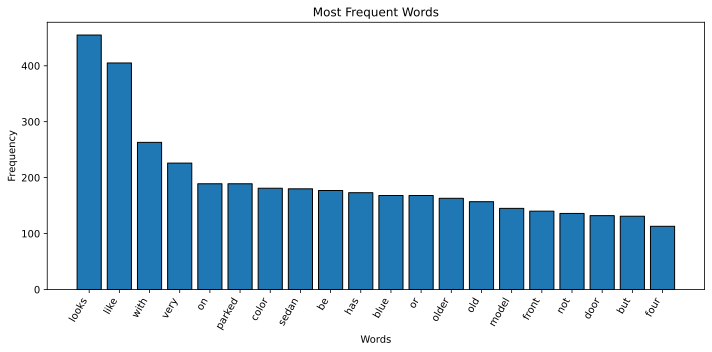

In [35]:
bar_frequency = plot_bargraph(filtered_frequency_df)

In [36]:
######## you can ignore this part for now!!!

######## freuqency of multiple words
######## not sure if I will include this part


from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    min_df=3
)

X_bigrams = bigram_vectorizer.fit_transform(clean_text)
bigram_counts = np.asarray(X_bigrams.sum(axis=0)).ravel()
bigram_names = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "bigram": bigram_names,
    "count": bigram_counts
}).sort_values("count", ascending=False)

bigram_df.head(20)

,bigram,count
307,looks like,271
97,car looks,110
106,car parked,71
479,sports car,62
382,older model,55
407,parking lot,53
248,license plate,39
33,blue car,35
424,red car,34
155,dark blue,34


### 2) Word Co-occurence

This step examines which words tend to appear together in the same response.

The idea is that co-occurring words may reflect a shared conceptual domain. (e.g., Words such as "quite" and "peaceful" may co-occur.)

In [37]:
def get_co_occurrence(some_text):
    co_occurrence = defaultdict(int)

    for text in some_text.dropna():
        tokens = text.split()

        unique_tokens = sorted(set(tokens))

        for w1, w2 in combinations(unique_tokens, 2):
            co_occurrence[(w1, w2)] += 1

    co_occurrence_df = pd.DataFrame(
        [(w1, w2, count) for (w1, w2), count in co_occurrence.items()],
        columns=["word_1", "word_2", "count"]
    ).sort_values("count", ascending=False).reset_index(drop=True)

    return co_occurrence_df

In [38]:
co_df = get_co_occurrence(clean_text)
co_df.head(30)

,word_1,word_2,count
0,a,car,516
1,a,the,387
2,car,the,384
3,a,is,375
4,a,it,373
5,car,is,355
6,a,and,333
7,and,car,327
8,a,in,311
9,is,the,308


In [39]:
filtered_co_df = remove_words(co_df, stopword_list, neutral_word_list)

#check
filtered_co_df.head(30)

,word_1,word_2,count
19,like,looks,257
181,parked,with,79
195,looks,with,76
199,looks,sedan,74
202,looks,or,73
213,door,four,72
218,looks,older,71
222,on,parked,69
226,parked,trees,69
228,blue,looks,68


In [40]:
#combine "word_1" and "word_2" columns
co_pair_df = filtered_co_df.copy()
co_pair_df["pair"] = co_pair_df["word_1"] + "-" + co_pair_df["word_2"]
co_pair_df = co_pair_df[["pair", "count"]]

#rename the column
co_pair_df = co_pair_df.rename(columns={"pair": "word"})

#check
co_pair_df

,word,count
19,like-looks,257
181,parked-with,79
195,looks-with,76
199,looks-sedan,74
202,looks-or,73
...,...,...
76572,lot-reflection,1
76573,might-tree,1
76574,not-office,1
76575,not-reflection,1


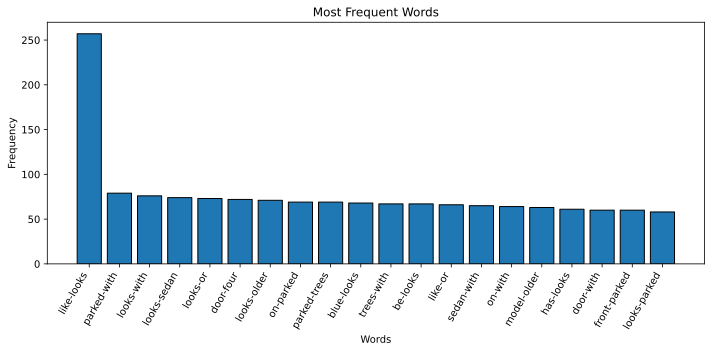

In [41]:
plot_bargraph(co_pair_df, top_n=20)

### 3) LDA Topic Modeling

Latent Dirichlet Allocation (LDA) will be used to identify the semantic clusters in participants’ free responses.

Once LDA suggests groups of words that tend to appear in similar response contexts, each group will be named into topics. (e.g., group A: "90s, 80s, old...etc" could be named "era")


**_how will i later make use of word frequency & co-occurrence data along with the LDA data?_**

In [45]:
def get_topic_words_df(model, feature_names, n_top_words=15):
    topic_rows = []

    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words-1:-1]
        top_words = [feature_names[i] for i in top_indices]

        topic_rows.append({
            "topic_number": topic_idx + 1,
            "top_words": ", ".join(top_words)
        })

    return pd.DataFrame(topic_rows)

In [48]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.95,
    min_df=5,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(clean_text)

# number of topics 
    # need to test with different numbers)
    # for the example dataset, = 4 ~ 8 seemed to work
n_topics = 6

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=0,
    learning_method="batch"
)

lda.fit(X)

feature_names = vectorizer.get_feature_names_out()
topics_df = get_topic_words_df(lda, feature_names, n_top_words=15)

print(topics_df)

   topic_number                                          top_words
0             1  car, like, color, looks, nice, look, looks lik...
1             2  car, old, model, probably, design, sports, spo...
2             3  looks, like, looks like, car, older, vehicle, ...
3             4  sedan, door, dark, car, blue, plate, license, ...
4             5  car, good, color, door, older, vehicle, red, a...
5             6  car, parked, looks, trees, lot, car parked, li...


In [51]:
#save as CSV
topics_df.to_csv(f"data/LDA_{n_topics}_topics.csv", index=False)

This process has to be tried out with different number of topics ("n_topics").

In [ ]:
## 3. Construct domain dictionaries

In the BCOG final project, we assumes that each topic has been named. The temporary topics for impression on cars are as follows:
- 1. Appearance / Style (body type/structure, color, sporty vs boxy, etc)
- 2. Evaluation (positive/negative impression)
- 3. Age / Era (old, vintage, modern, new)
- 4. Condition / Functionality (clean/worn, reliable, fast, powerful, gas mileage…)
- 5. Context / Environment (where the car is / surroundings)

In [ ]:
## 4. Code responses into domains

In [ ]:
## 5. Compute domain prevalence